# Notebook 05 - Normalisation and Aggregation

This notebook normalises all indicator variables and combines them into the four sub-indices and a final CRI score.

**Steps:**
1. Load the cleaned data and the list of kept variables from notebook 03
2. Apply min-max normalisation to all indicator variables (scales everything to 0-1)
3. Map each variable to one of the four sub-indices
4. Calculate each sub-index as the mean of its normalised variables
5. Calculate the final CRI score as a weighted average of the four sub-indices (equal weights: 0.25 each)
6. Rank countries and save results to `data/processed/cri_scores.csv`

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

PROCESSED = '../data/processed/'

df = pd.read_csv(f'{PROCESSED}clustered_data.csv')
kept_vars = pd.read_csv(f'{PROCESSED}kept_variables.csv')['kept_variables'].tolist()

print(f'Loaded shape: {df.shape}')
print(f'Kept variables: {kept_vars}')
display(df.head())

Loaded shape: (35, 14)
Kept variables: ['ncsi_score', 'gci_capacity', 'gci_cooperation', 'gci_legal', 'gci_organisational', 'gci_technical', 'internet_penetration']


,country,gci_overall,ncsi_score,ddl_score,gci_capacity,gci_cooperation,gci_legal,gci_organisational,gci_technical,internet_penetration,gdp_per_capita,hdi_score,cluster_kmeans,cluster_hierarchical
0,Argentina,50.12,63.64,60.43,3.135239,9.983615,14.553914,10.186348,12.962927,89.228972,14261.846567,0.849,1,4
1,Australia,97.47,66.23,77.61,19.720586,19.127009,20.000000,19.490706,18.516867,96.116096,65058.377315,0.946,0,1
2,Austria,93.89,68.83,75.76,18.735104,17.143173,18.924699,17.599348,19.115610,95.334671,56579.504175,0.926,3,3
3,Belgium,96.25,94.81,74.07,19.596973,20.000000,20.000000,17.884250,19.055728,94.626251,55291.475454,0.942,0,1
4,Brazil,96.60,51.95,59.11,19.367390,19.703050,20.000000,18.137006,19.363917,84.150602,10377.589772,0.760,0,1


## 1. Min-Max Normalisation

Min-max normalisation rescales each variable to the range [0, 1] using the formula:

```
x_norm = (x - x_min) / (x_max - x_min)
```

This makes all variables directly comparable regardless of their original units or scale. A score of 1 means the country with the highest value in the dataset for that variable; 0 means the lowest.

**Outliers as unintended benchmarks:** One important limitation of min-max normalisation is that extreme outliers set the floor or ceiling. Argentina has GCI pillar scores (capacity: 3.1, cooperation: 10.0, organisational: 10.2) that are far below every other country. These values will anchor the minimum for those variables, which means all other countries get compressed into the upper part of the 0-1 range. This is documented here but no transformation is applied -- Argentina's low scores are real, not data errors, and removing it would misrepresent the actual variation across countries.

In [19]:
scaler = MinMaxScaler()

# Only normalise the indicator variables (not benchmark or cluster columns)
X = df[kept_vars].copy()
X_norm = pd.DataFrame(
    scaler.fit_transform(X),
    columns=[f'{col}_norm' for col in kept_vars]
)

print(f'Normalised shape: {X_norm.shape}')
print(f'Min values (should all be 0):\n{X_norm.min().values}')
print(f'Max values (should all be 1):\n{X_norm.max().values}')
display(X_norm.describe().round(3))

Normalised shape: (35, 7)
Min values (should all be 0):
[0. 0. 0. 0. 0. 0. 0.]
Max values (should all be 1):
[1. 1. 1. 1. 1. 1. 1.]


,ncsi_score_norm,gci_capacity_norm,gci_cooperation_norm,gci_legal_norm,gci_organisational_norm,gci_technical_norm,internet_penetration_norm
count,35.000,35.000,35.000,35.000,35.000,35.000,35.000
mean,0.616,0.891,0.870,0.903,0.821,0.824,0.815
std,0.277,0.192,0.216,0.211,0.207,0.193,0.224
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.480,0.892,0.813,0.920,0.750,0.760,0.804
50%,0.592,0.962,0.970,1.000,0.887,0.889,0.887
75%,0.847,0.986,1.000,1.000,0.948,0.951,0.946
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### Skewness Check

The OECD Handbook recommends checking for highly skewed indicators (|skewness| > 1) and transforming them if necessary, since skewed distributions can distort min-max scaling. We check the original variables before normalisation.

In [20]:
skewness = df[kept_vars].skew().round(3)
skew_df = pd.DataFrame({'skewness': skewness})
skew_df['highly_skewed'] = skew_df['skewness'].abs() > 1
print('=== Skewness of Indicator Variables ===')
display(skew_df)

highly_skewed = skew_df[skew_df['highly_skewed']].index.tolist()
if highly_skewed:
    print(f'\nHighly skewed variables (|skew| > 1): {highly_skewed}')
    print('Consider log transformation for these variables.')
else:
    print('\nNo variables with |skewness| > 1. No transformation required.')

=== Skewness of Indicator Variables ===


,skewness,highly_skewed
ncsi_score,-0.550,False
gci_capacity,-3.378,True
gci_cooperation,-2.549,True
gci_legal,-3.104,True
gci_organisational,-2.291,True
gci_technical,-2.505,True
internet_penetration,-2.522,True



Highly skewed variables (|skew| > 1): ['gci_capacity', 'gci_cooperation', 'gci_legal', 'gci_organisational', 'gci_technical', 'internet_penetration']
Consider log transformation for these variables.


## 2. Sub-Index Mapping

Each kept variable is assigned to one of the four sub-indices based on what it measures. Only variables that exist in `kept_vars` are included. This mapping reflects the theoretical framework defined at the start of the project.

In [21]:
SUB_INDEX_MAP = {
    'technical_capacity':      ['internet_penetration', 'gci_technical', 'ncsi_score'],
    'legal_regulatory':        ['gci_legal'],
    'capacity_building':       ['gci_capacity'],
    'organisational_measures': ['gci_organisational', 'gci_cooperation'],
}

normalised_col_names = [f'{v}_norm' for v in kept_vars]
active_map = {}
for sub_index, variables in SUB_INDEX_MAP.items():
    active = [f'{v}_norm' for v in variables if f'{v}_norm' in normalised_col_names]
    active_map[sub_index] = active
    print(f'{sub_index}: {active}')

technical_capacity: ['internet_penetration_norm', 'gci_technical_norm', 'ncsi_score_norm']
legal_regulatory: ['gci_legal_norm']
capacity_building: ['gci_capacity_norm']
organisational_measures: ['gci_organisational_norm', 'gci_cooperation_norm']


## 3. Calculate Sub-Index Scores

Each sub-index score is the simple mean of its normalised variables. Equal weighting within sub-indices is chosen because there is no empirical basis to prioritise one variable over another inside the same dimension.

In [22]:
results = pd.DataFrame({'country': df['country'].values})

for sub_index, variables in active_map.items():
    if not variables:
        print(f'WARNING: no variables mapped to {sub_index} - assigning 0')
        results[sub_index] = 0.0
    else:
        results[sub_index] = X_norm[variables].mean(axis=1)

print('Sub-index scores calculated:')
display(results.round(3))

Sub-index scores calculated:


,country,technical_capacity,legal_regulatory,capacity_building,organisational_measures
0,Argentina,0.455,0.000,0.000,0.000
1,Australia,0.766,1.000,0.983,0.930
2,Austria,0.804,0.803,0.925,0.735
3,Belgium,0.933,1.000,0.976,0.892
4,Brazil,0.671,1.000,0.962,0.890
5,Canada,0.694,0.899,0.970,0.985
6,China,0.617,1.000,0.929,0.787
7,Czech Republic,0.787,0.898,0.629,0.538
8,Denmark,0.919,0.936,0.985,0.871
9,Estonia,0.853,1.000,0.977,1.000


## 4. Calculate Final CRI Score

The final CRI score is a weighted average of the four sub-indices. Equal weights (0.25 each) are used because there is no strong theoretical or empirical basis for prioritising one dimension of cybersecurity readiness over another. This is consistent with the approach taken by the ITU GCI and the OECD Handbook default when expert judgement is not available.

**Correlation among indicators:** High correlations between variables were already addressed in notebook 03 (ddl_score was removed due to r=0.869 with internet_penetration). The 7 remaining variables are sufficiently distinct that double-counting is not a significant concern at the aggregation stage.

**Compensability:** Using an arithmetic mean (additive aggregation) allows full compensability -- a country with a very low score in one sub-index can partially offset it with high scores in others. This is a known trade-off of additive aggregation. The alternative, a geometric mean, would penalise unbalanced profiles more heavily but is harder to interpret. Given that the CRI is designed as a general readiness overview rather than a minimum-threshold assessment, full compensability is considered acceptable here.

In [23]:
SUB_INDEX_WEIGHTS = {
    'technical_capacity':     0.25,
    'legal_regulatory':       0.25,
    'capacity_building':      0.25,
    'organisational_measures':0.25,
}

results['cri_score'] = sum(
    results[sub] * weight
    for sub, weight in SUB_INDEX_WEIGHTS.items()
)

# Rank countries by CRI score (rank 1 = highest)
results['cri_rank'] = results['cri_score'].rank(ascending=False).astype(int)
results = results.sort_values('cri_rank').reset_index(drop=True)

print('Final CRI scores and rankings:')
display(results.round(3))

Final CRI scores and rankings:


,country,technical_capacity,legal_regulatory,capacity_building,organisational_measures,cri_score,cri_rank
0,United Kingdom,0.944,1.000,1.000,1.000,0.986,1
1,Spain,0.937,1.000,0.992,0.974,0.976,2
2,Estonia,0.853,1.000,0.977,1.000,0.957,3
3,Germany,0.887,1.000,0.982,0.959,0.957,4
4,Portugal,0.907,1.000,0.947,0.974,0.957,5
5,Netherlands,0.925,1.000,0.942,0.959,0.957,6
6,South Korea,0.845,1.000,1.000,0.974,0.955,7
7,Singapore,0.843,1.000,0.996,0.974,0.953,8
8,United States,0.816,1.000,0.996,1.000,0.953,9
9,Finland,0.925,1.000,0.952,0.934,0.953,10


## 5. Sub-Index Score Distribution

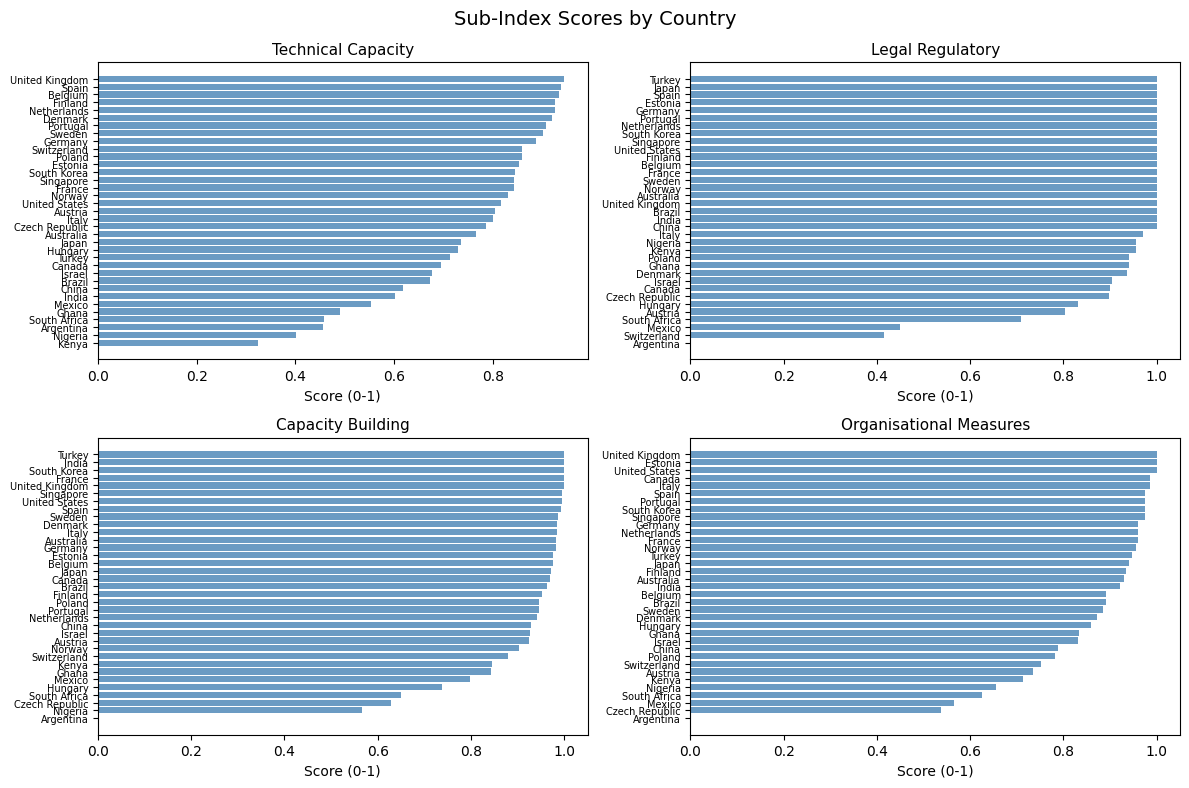

Saved: report/figures/05_subindex_distributions.png


In [24]:
sub_index_cols = list(SUB_INDEX_WEIGHTS.keys())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, sub_index_cols):
    sorted_data = results.sort_values(col, ascending=True)
    ax.barh(sorted_data['country'], sorted_data[col], color='steelblue', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Score (0-1)')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Sub-Index Scores by Country', fontsize=14)
plt.tight_layout()
plt.savefig('../report/figures/05_subindex_distributions.png', dpi=150)
plt.show()
print('Saved: report/figures/05_subindex_distributions.png')

## 6. Save CRI Scores

Attach benchmark columns (`gci_overall`, `hdi_score`, `gdp_per_capita`) so notebook 06 can run the regression comparison from a single file, then save everything to `data/processed/cri_scores.csv`.

In [25]:
benchmark_cols = ['country', 'gci_overall', 'hdi_score', 'gdp_per_capita']
available_benchmarks = [c for c in benchmark_cols if c in df.columns]
benchmarks = df[available_benchmarks].copy()
results = results.merge(benchmarks, on='country', how='left')

output_path = f'{PROCESSED}cri_scores.csv'
results.to_csv(output_path, index=False)
print(f'Saved CRI scores to {output_path}')
print(f'Shape: {results.shape}')
display(results[['country', 'cri_rank', 'cri_score'] + sub_index_cols].round(3))

Saved CRI scores to ../data/processed/cri_scores.csv
Shape: (35, 10)


,country,cri_rank,cri_score,technical_capacity,legal_regulatory,capacity_building,organisational_measures
0,United Kingdom,1,0.986,0.944,1.000,1.000,1.000
1,Spain,2,0.976,0.937,1.000,0.992,0.974
2,Estonia,3,0.957,0.853,1.000,0.977,1.000
3,Germany,4,0.957,0.887,1.000,0.982,0.959
4,Portugal,5,0.957,0.907,1.000,0.947,0.974
5,Netherlands,6,0.957,0.925,1.000,0.942,0.959
6,South Korea,7,0.955,0.845,1.000,1.000,0.974
7,Singapore,8,0.953,0.843,1.000,0.996,0.974
8,United States,9,0.953,0.816,1.000,0.996,1.000
9,Finland,10,0.953,0.925,1.000,0.952,0.934
